# Pauli Propagation

In [ ]:
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp, commutator

from math import cos, sin
from functools import partial
from tqdm import tqdm
import numpy as np
from numpy.linalg import matrix_power

from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf, expH
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from pauli import *

fig_dir, data_dir = './figs', './data'
set_fontsize(linewidth=2.0)

## Setup: Hamiltonian, Trotter, and initial state

In [ ]:
n = 8
t = 5  # t = n
t_num = 100
r = 10

hx, hy, Jx = 1, 0.9, 0.8
H_model = 'mfi'
if H_model == 'tfi':
    qimf = Nearest_Neighbour_1d(n, hy=hy, Jx=Jx, pbc=False)
else:
    print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
    qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par
# H_ordered = sum(H_list[1][::-1], H_list[0])
H_ordered = sum(H_list)
assert H_ordered.equiv(sum(qimf.ham))
num_terms = len(qimf.ham)
print(f'Hamiltonian terms: {num_terms}')

dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_list), dt, use_jax=False)
U_dt_appro = pf(H_list, dt, 1, 1)
# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1) + SparsePauliOp('I'*(n-3)+'XXZ', 1)
# z1 = SparsePauliOp('I'*(n-2)+'ZZ', 1) + SparsePauliOp('I'*(n-1)+'Z', 1)
# z1 = SparsePauliOp('I'*(n-2)+'XX', 1) + SparsePauliOp('I'*(n-1)+'X', 1)
commutator(qimf.ham[0], qimf.ham[3]).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j]))

U_dt_ideal_dense = expH(sum(H_list), t/t_num, use_jax=False)
ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal_dense, i)@init_state) for i in range(t_num+1)]
trott_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_appro, i)@init_state) for i in range(r+1)]

print('even-odd grouping: ', qimf.ham_par)
print('ob: ', z1)
# for g in list(qimf.ham.paulis):
# for g in list(sum(qimf.ham_par).paulis):
#     print(g)

QIMF model with hx=1, hy=0.9, Jx=0.8, n=8
Hamiltonian terms: 23
t=5, r=10, dt=0.5
even-odd grouping:  [SparsePauliOp(['IIIIIIXX', 'IIIIXXII', 'IIXXIIII', 'XXIIIIII', 'IIIIIIIX', 'IIIIIXII', 'IIIXIIII', 'IXIIIIII', 'IIIIIIIY', 'IIIIIYII', 'IIIYIIII', 'IYIIIIII'],
              coeffs=[0.8+0.j, 0.8+0.j, 0.8+0.j, 0.8+0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j,
 0.9+0.j, 0.9+0.j, 0.9+0.j, 0.9+0.j]), SparsePauliOp(['IIIIIXXI', 'IIIXXIII', 'IXXIIIII', 'IIIIIIXI', 'IIIIXIII', 'IIXIIIII', 'XIIIIIII', 'IIIIIIYI', 'IIIIYIII', 'IIYIIIII', 'YIIIIIII'],
              coeffs=[0.8+0.j, 0.8+0.j, 0.8+0.j, 1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.9+0.j,
 0.9+0.j, 0.9+0.j, 0.9+0.j])]
ob:  SparsePauliOp(['IIIIIIIZ'],
              coeffs=[1.+0.j])


## Evolution

In [209]:
print(cos(dt)**2, sin(dt)**2, dt**2)
## observable evolution
evo_ob = [z1]
w_thres = 4
evo_ob_untrunc = [z1]
is_trunc = True

for i in tqdm(range(r)):
    # print('+', end='')
    # for g in list(qimf.ham):
    for g in list(H_ordered):
        # print(g)
        temp = []
        for item in list(evo_ob[-1]):
            # print(item)
            if commutator(g, item).simplify().equiv(SparsePauliOp(['I'*n], coeffs=[0.+0.j])):
                # print(item, g)
                temp.append(item)
            else:
                norm_g = SparsePauliOp(g.paulis, coeffs=[1])  
                angle = 2*dt*g.coeffs[0].real
                branch = math.cos(angle)*item + 1j*math.sin(angle)*norm_g@item
                # branch = pauli_rotation_evo(g, dt, item, coeffs=[c,s])
                # branch = c*item + 1j*s*g@item
                temp.append(branch)
        ob_g = sum(temp).simplify()
        # temp_step.append(ob_g)
        evo_ob.append(ob_g)
        # print(f"#Pauli={len(list(ob_g))}, 2-norm={np.linalg.norm(ob_g, ord='fro')/ np.sqrt(2**n)}")
    evo_ob_untrunc.append(ob_g)
    print(len(evo_ob[-1]))
    # print(len(evo_ob[-1]), evo_ob[-1])
    if is_trunc:
        evo_ob[-1] = truncate_high_weight_pauli(ob_g, w_thres)
# print('evo_ob:', evo_ob)

0.7701511529340699 0.22984884706593015 0.25


 20%|██        | 2/10 [00:00<00:00, 14.92it/s]

9
27
55


 40%|████      | 4/10 [00:01<00:01,  3.41it/s]

183


...

 80%|████████  | 8/10 [00:40<00:19,  9.94s/it]

7037
11523


 90%|█████████ | 9/10 [01:25<00:20, 20.47s/it]

44116


100%|██████████| 10/10 [03:17<00:00, 19.77s/it]


In [149]:
test = evo_ob[-1]
print(len(test), test)
truncate_high_weight_pauli(test, 4)

8 SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY', 'IIIIXYYY', 'IIIIZYYY'],
              coeffs=[-0.053342+0.j, -0.267918+0.j,  0.040517+0.j, -0.025513+0.j,  0.069075+0.j,
 -0.536173+0.j,  0.406538+0.j,  0.328003+0.j])


SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIXYY', 'IIIIIZYY', 'IIIIXYYY', 'IIIIZYYY'],
              coeffs=[-0.053342+0.j, -0.267918+0.j,  0.040517+0.j, -0.025513+0.j,  0.069075+0.j,
 -0.536173+0.j,  0.406538+0.j,  0.328003+0.j])

In [ ]:
print(low_weight_pauli(evo_ob[-1], 3))

# expvals, expvals_1, expvals_3, expvals_6 = [], [], [], []
expvals, expvals_low, expvals_w = [], [], []
for item in evo_ob[::num_terms]:
    expvals.append(expect_value(item.to_matrix(), init_state))
    # expvals_1.append(expect_value(low_weight_pauli(item, 1).to_matrix(), init_state))
    temp_w, temp_low = [], []
    for w in range(1, n+1):
        temp_w.append(abs(expect_value(w_weight_pauli(item, w).to_matrix(), init_state)))
        temp_low.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
        # temp.append(expect_value(low_weight_pauli(item, w).to_matrix(), init_state))
    expvals_w.append(temp_w)
    expvals_low.append(temp_low)
expvals_w, expvals_low = np.array(expvals_w), np.array(expvals_low)

data_distribution = []
# exp_vals = []
for item in evo_ob[::num_terms]:
    weight_norm_dict = pauli_weight_norm(item)
    # print(len(list(item)), weight_norm_dict)
    data_distribution.append(weight_norm_dict)

norm_weight_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    for w in range(1, n+1):
        if w in item:
            temp_step.append(item[w])
        else:
            temp_step.append(0)
    norm_weight_steps.append(temp_step)
print('norm_weight_steps:', norm_weight_steps)

SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIIY', 'IIIIIIXY', 'IIIIIIZY', 'IIIIIIXZ', 'IIIIIIZZ', 'IIIIIIXX', 'IIIIIIZX', 'IIIIIIYY', 'IIIIIXYY', 'IIIIIXZY', 'IIIIIXXY', 'IIIIIIYZ', 'IIIIIXYZ', 'IIIIIXZZ', 'IIIIIXXZ', 'IIIIIIYX', 'IIIIIXYX', 'IIIIIXZX', 'IIIIIXXX', 'IIIIIIYI', 'IIIIIIZI', 'IIIIIIXI', 'IIIIIXZI', 'IIIIIXXI', 'IIIIIXYI', 'IIIIIZYY', 'IIIIIZZY', 'IIIIIZXY', 'IIIIIZYZ', 'IIIIIZZZ', 'IIIIIZXZ', 'IIIIIZYX', 'IIIIIZZX', 'IIIIIZXX', 'IIIIIYIY', 'IIIIIYIZ', 'IIIIIYIX', 'IIIIIXIZ', 'IIIIIZIZ', 'IIIIIYXZ', 'IIIIIYZZ', 'IIIIIXIX', 'IIIIIZIX', 'IIIIIYXX', 'IIIIIYZX', 'IIIIIXIY', 'IIIIIZIY', 'IIIIIYXY', 'IIIIIYZY', 'IIIIIZZI', 'IIIIIZXI', 'IIIIIZYI', 'IIIIIYII', 'IIIIIYYY', 'IIIIIYYZ', 'IIIIIYYX', 'IIIIXIZY', 'IIIIZIZY', 'IIIIXIXY', 'IIIIZIXY', 'IIIIXIYY', 'IIIIZIYY', 'IIIIXIZZ', 'IIIIZIZZ', 'IIIIXIXZ', 'IIIIZIXZ', 'IIIIXIYZ', 'IIIIZIYZ', 'IIIIXIZX', 'IIIIZIZX', 'IIIIXIXX', 'IIIIZIXX', 'IIIIXIYX', 'IIIIZIYX', 'IIIIXZIY', 'IIIIZZIY', 'IIIIXYIY', 'IIIIZYIY', 'IIIIXZIZ', 'IIIIZZIZ', '

In [ ]:
expvals_low_part = [expect_value(item.to_matrix(), init_state) for item in evo_ob_untrunc]
print(expvals_low_part)
print(expvals_low[:, w_thres])

## Low-weight (truncated) Evolution

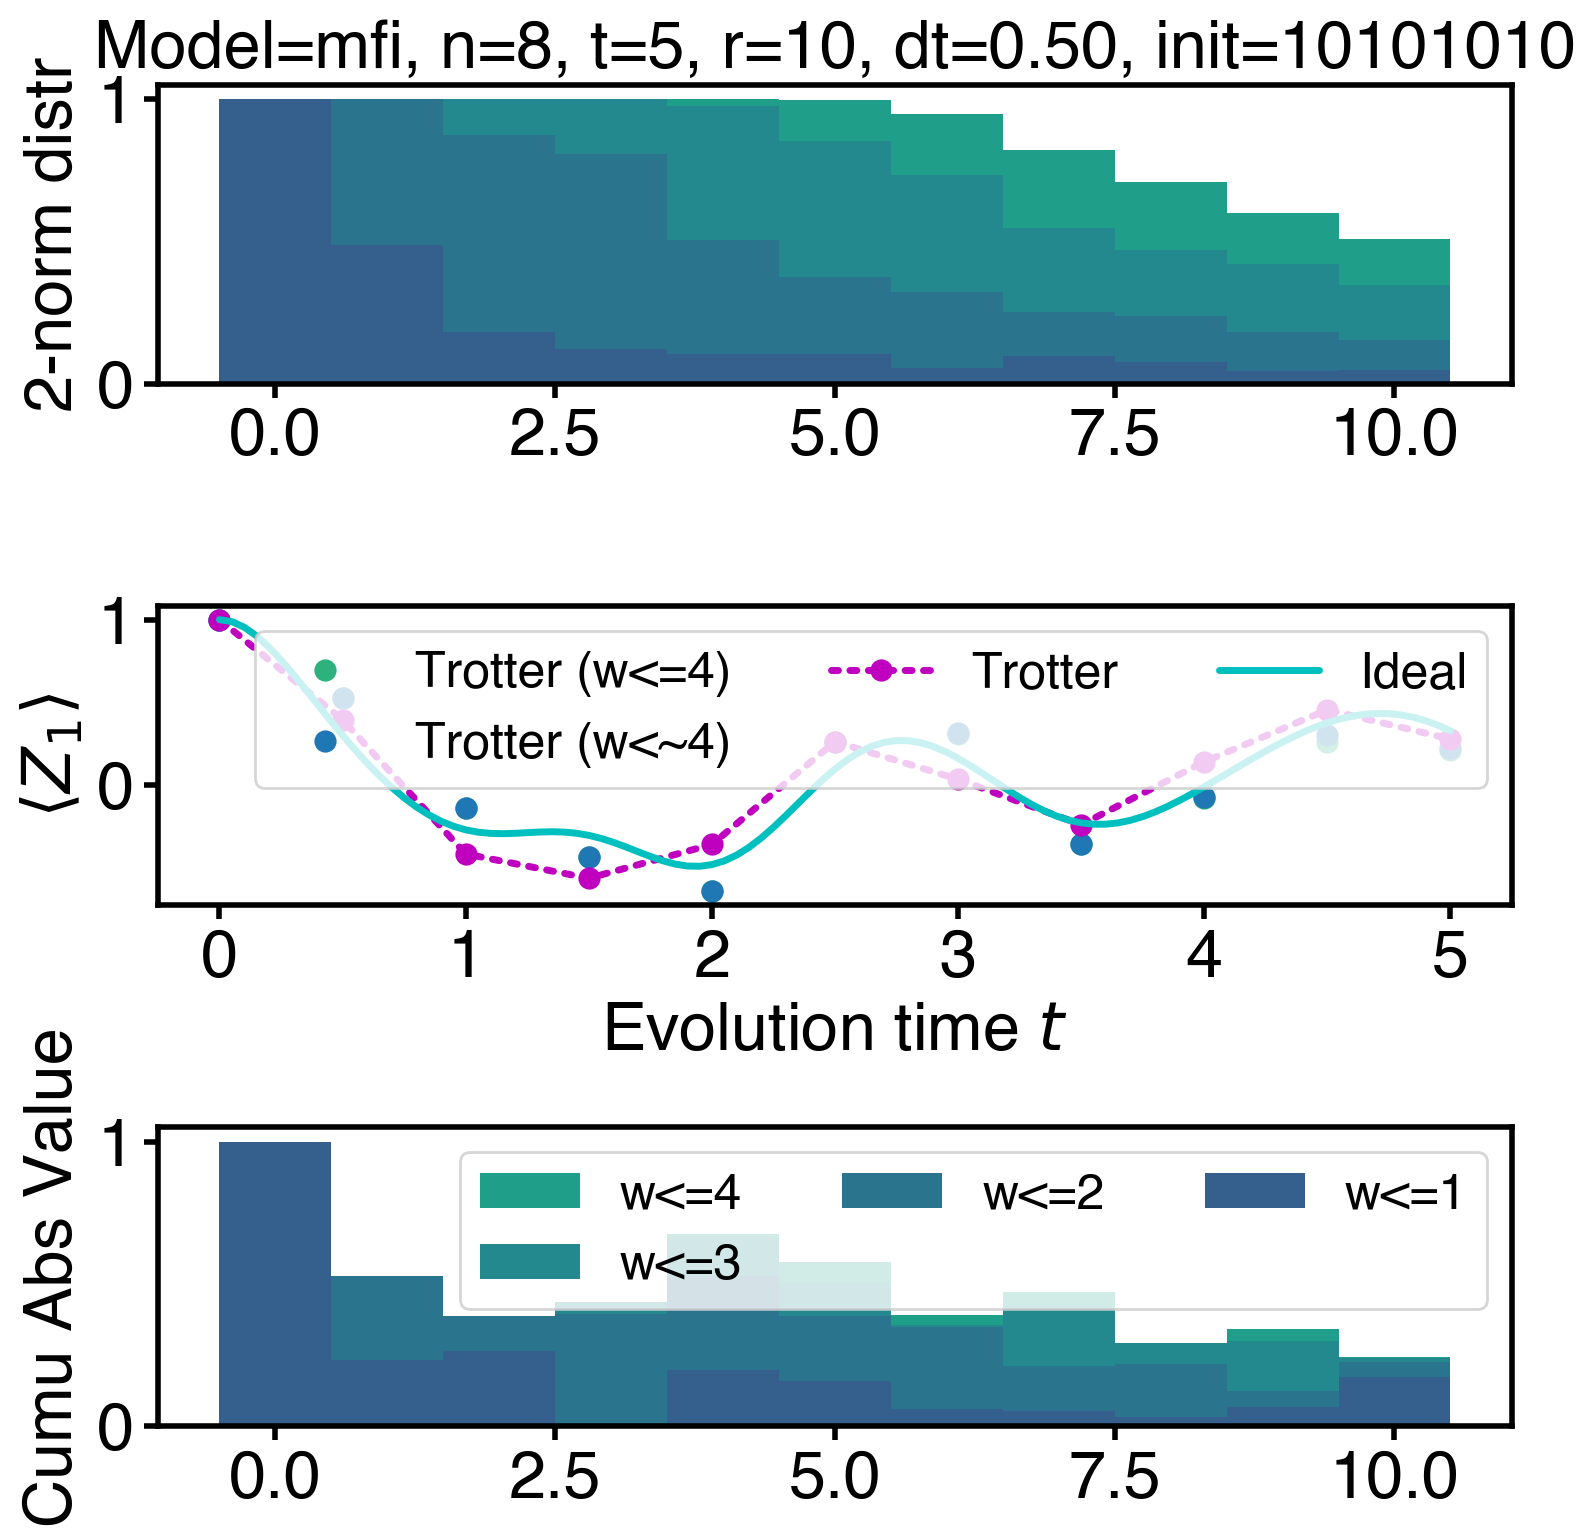

In [219]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num
t_list = np.array(range(len(trott_expvals))) * t/r

# Use wider spacing between bars for better visibility
x_pos = np.arange(len(expvals_w)) 
bar_width, alpha = 1.0, 1
colors = plt.cm.viridis(np.linspace(0.3, 0.9, n))

fig, [ax3, ax, ax2] = plt.subplots(3, 1, sharex=False, figsize=(8, 8))
# ax.plot(t_list, expvals_low[:, 0], '--', label='Trotter (w<=1)', color=colors[0])
ax.plot(t_list, expvals_low[:, w_thres], '.', label=rf'Trotter (w<={w_thres})', color=colors[w_thres])
ax.plot(t_list, expvals_low_part, '.', label=rf'Trotter (w<~{w_thres})')
ax.plot(t_list, trott_expvals, ':.', label='Trotter', c='m')
ax.plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='c')
# ax.plot(t_list, expvals_low[:, 5], '--', label='Trotter (w<=5)', color=colors[5])
# ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'$\langle Z_1 \rangle$')
ax.legend(loc='upper right', ncol=3, fontsize='medium')

# Plot with different alpha values for better layering effect
for w in range(w_thres, 0, -1):
# for w in range(w_thres, 0, -1):
    cumulative_values = [sum(expvals_w[i][:w]) for i in range(len(expvals_w))]
    bars = ax2.bar(x_pos, cumulative_values, bar_width, color=colors[w-1], alpha=alpha, label=f'w<={w}')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(expvals_w))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = ax3.bar(x_pos, norm2_distr, bar_width, color=colors[w-1], label=f'w<={w}')

# print(x_pos)
# ax2.set_xlabel('Trotter Steps')
ax2.set_ylabel('Cumu Abs Value')
ax2.legend(loc='upper right', ncol=3, fontsize='medium')  # make legend horizontal

# ax2.set_xlabel('Trotter Steps')
ax3.set_ylabel('2-norm distr') # ax3.legend(loc='upper right')
ax3.set_title(rf'Model={H_model}, n={n}, t={t}, r={r}, dt={dt:.2f}, init={init_state_str}')
ax.set_xlabel(rf'Evolution time $t$')

# fig.savefig(f'{fig_dir}/expvals_pauli_t={t}_{t_num}.pdf', bbox_inches='tight')
fig.savefig(f'{fig_dir}/expvals_pauli_{H_model}_t={t}_{t_num}_w={w}_{init_state_str}.pdf', bbox_inches='tight')

## Ideal Evolution

w>=8, 0.6344139550161207
w>=7, 0.6344139550161207
w>=6, 0.6344139550161207
w>=5, 0.6344139550161207
w>=4, 0.8768669036423988
w>=3, 0.9395104812480366
w>=2, 0.9684329564028321


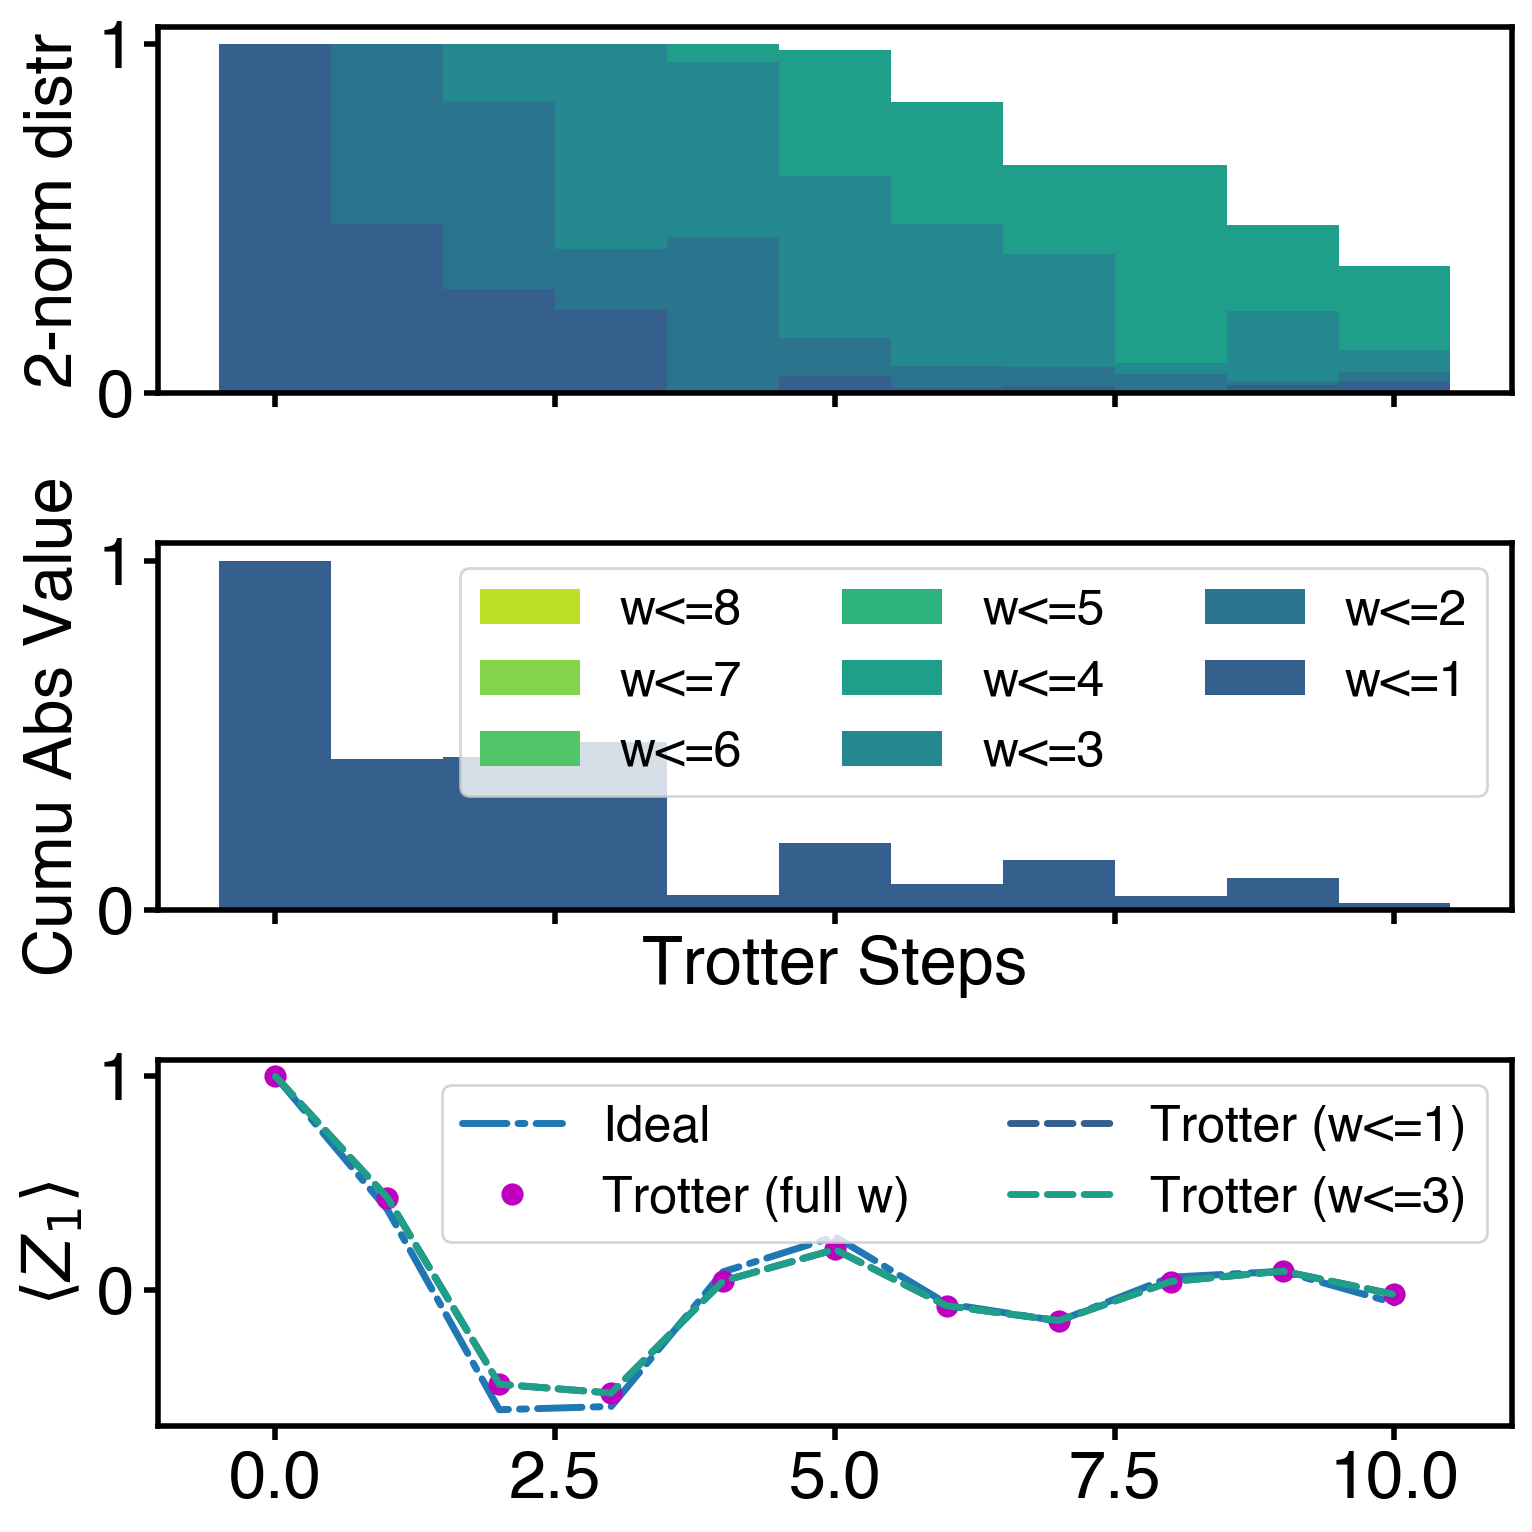

In [ ]:
t_list = list(range(len(expvals)))

# Use wider spacing between bars for better visibility
x_pos = np.arange(len(expvals_w)) 
bar_width = 1.0
k = n
# colors = plt.cm.viridis(np.linspace(0.9, 0.1, k))
# colors = plt.cm.viridis(np.linspace(0.0, 1, k))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, k))

fig, [ax3, ax2, ax] = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
ax.plot(range(len(ideal_expvals)), ideal_expvals, '-.', label='Ideal')
ax.plot(t_list, expvals, '.', label='Trotter (full w)', c='m')
ax.plot(t_list, expvals_low[:, 0], '--', label='Trotter (w<=1)', color=colors[0])
ax.plot(t_list, expvals_low[:, 1], '--', label='Trotter (w<=3)', color=colors[3])
# ax.plot(t_list, expvals_low[:, 5], '--', label='Trotter (w<=5)', color=colors[5])
# ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'$\langle Z_1 \rangle$')
ax.legend(loc='upper right', ncol=2, fontsize='medium')

# Plot with different alpha values for better layering effect
for w in range(n, 0, -1):
    cumulative_values = [sum(expvals_w[i][:w]) for i in range(len(expvals_w))]
    # Vary alpha based on w value
    # alpha = 0.6 + (w / n) * 0.4
    alpha = 1
    bars = ax2.bar(x_pos, cumulative_values, bar_width, color=colors[w-1], alpha=alpha, label=f'w<={w}')
# for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(expvals_w))]

    if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = ax3.bar(x_pos, norm2_distr, bar_width, color=colors[w-1], label=f'w<={w}')
# print(x_pos)
# ax2.set_xlabel('Trotter Steps')
ax2.set_ylabel('Cumu Abs Value')
# ax2.set_title('Cumulative Values with Enhanced Visibility')
ax2.legend(loc='upper right', ncol=3, fontsize='medium')  # make legend horizontal

ax2.set_xlabel('Trotter Steps')
ax3.set_ylabel('2-norm distr') # ax3.legend(loc='upper right')
ax3.set_xlabel(rf'Evolution time $t$')

# fig.savefig(f'{fig_dir}/expvals_pauli_t={t}_{t_num}.pdf', bbox_inches='tight')
fig.savefig(f'{fig_dir}/expvals_pauli_t={t}_{t_num}_{init_state_str}.pdf', bbox_inches='tight')

In [86]:
from math import cos, sin
t = 0.05
c2_IZ, c2_XY, c2_XX = cos(2*t), cos(2*t)*sin(2*t), sin(2*t)**2
print(c2_IZ, c2_XY, c2_XX)
print(c2_IZ**2 + c2_XY**2 + c2_XX**2)

c, s = cos(t), sin(t)
c1_IZ, c1_XY, c1_XX = c**2-c*s**2, c**2*s+c**3*s-s**3, 2*c*s**2+c**2*s**2
print(c1_IZ, c1_XY, c1_XX)
print(c1_IZ**2 + c1_XY**2 + c1_XX**2)

0.9950041652780258 0.09933466539753062 0.009966711079379185
1.0
0.995007287024282 0.09952150211255016 0.007481268999306777
1.0000000000000002


In [ ]:
test = evo_ob[8]
print(test)
print(sum([coeff**2 for coeff in test.coeffs]))
c, s = math.cos(dt*2), math.sin(dt*2)
pauli_weight_norm(test)

SparsePauliOp(['IIIIIIIZ', 'IIIIIIIX', 'IIIIIIXY'],
              coeffs=[ 0.829367+0.j, -0.40063 +0.j,  0.389418+0.j])
(1+0j)


{1: 0.8483533546735826, 2: 0.1516466453264173}

## Legacy

In [ ]:

cumulative_norm_steps = []
for i, item in enumerate(data_distribution):
    temp_step = []
    # print(item)
    for w in range(1, n+1):
        temp_sum = 0
        for k in range(w, n+1):
            if k in item:
                # print('k', k, item[k])
                temp_sum += item[k]
        # print('sum',temp_sum)
        temp_step.append(temp_sum)
        # print(item, temp_step)
    cumulative_norm_steps.append(temp_step)
print('cumulative_norm_steps:', cumulative_norm_steps)

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(cumulative_norm_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(cumulative_norm_steps[0])):
    ax.plot(range(len(cumulative_norm_steps)), np.array(cumulative_norm_steps)[:,w], label=f'w>={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'Cumulative norm')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/cumulative_norm_steps.pdf', bbox_inches='tight')

norm_weight_steps: [[1.0, 1.0, 0, 0, 0, 0, 0, 0], [1.0000209489808225, 0.9999790510191775, 0, 0, 0, 0, 0, 0], [1.0001814226773924, 0.9996317403690785, 0.00018683695352863014, 0, 0, 0, 0, 0], [1.0006887226214014, 0.9985808327541053, 0.0007304338649076543, 1.0759792488277703e-08, 0, 0, 0, 0], [1.0017816765338718, 0.9962494154484095, 0.0019688141872421703, 9.383051283962442e-08, 4.3505756510723055e-13, 0, 0, 0], [1.0036580972809943, 0.99207228453723, 0.004269126621030906, 4.915545006337152e-07, 6.7408702845783305e-12, 0, 0, 0], [1.006396964232906, 0.9855885595642544, 0.008012596116044953, 1.8800297335878313e-06, 5.7748814222423213e-11, 1.847907130033839e-16, 0, 0], [1.0098888042257421, 0.9765441718396173, 0.013561231337695438, 5.7922551123929354e-06, 3.426426038059433e-10, 3.7441992831475595e-15, 0, 0], [1.0137861273197215, 0.9649665739930966, 0.02123206714655115, 1.5229972456092651e-05, 1.5690453679054512e-09, 3.870156791508872e-14, 0, 0], [1.0174831425781299, 0.951199300579965, 0.031282

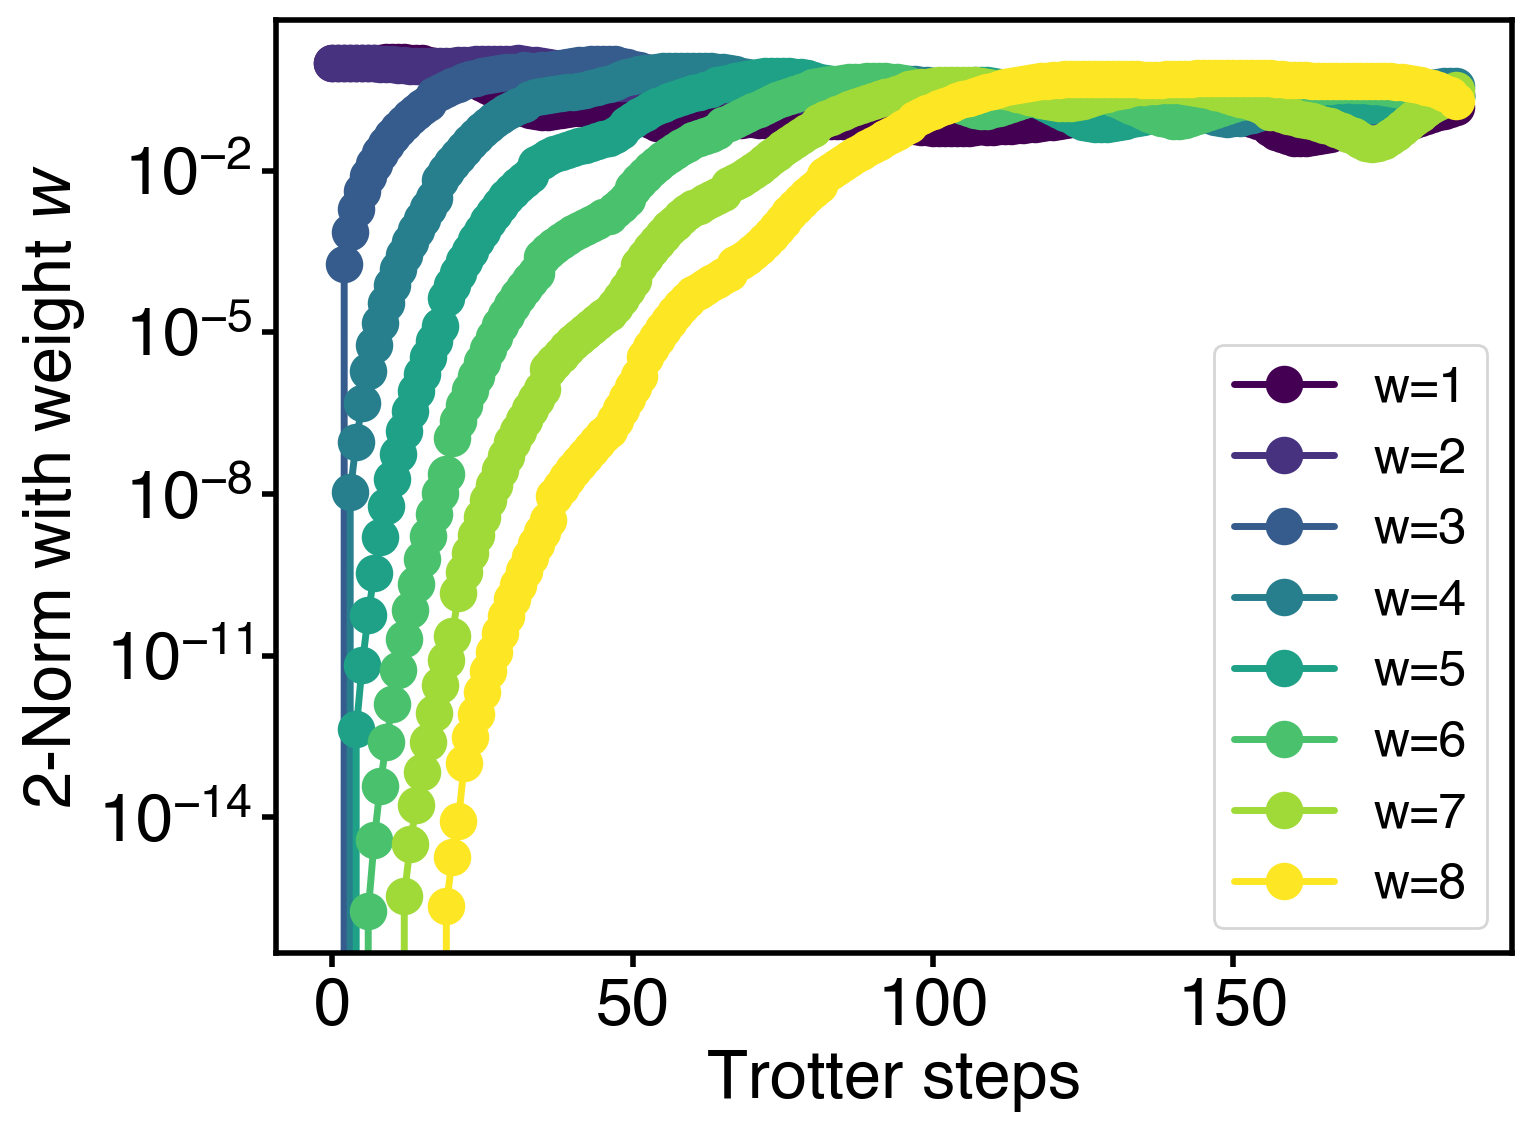

In [ ]:

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(norm_weight_steps[0])))
ax.set_prop_cycle(color=colors)
for w in range(len(norm_weight_steps[0])):
    ax.plot(range(len(norm_weight_steps)), np.array(norm_weight_steps)[:, w], label=f'w={w+1}', marker='o')
ax.set_xlabel(fr'Trotter steps')
ax.set_ylabel(rf'2-Norm with weight $w$')
# ax.set_title('Cumulative norm of Pauli operators at each step')
ax.set_yscale('log')
ax.legend()
fig.savefig(f'{fig_dir}/norm_weight_steps.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'Pauli weight distribution')

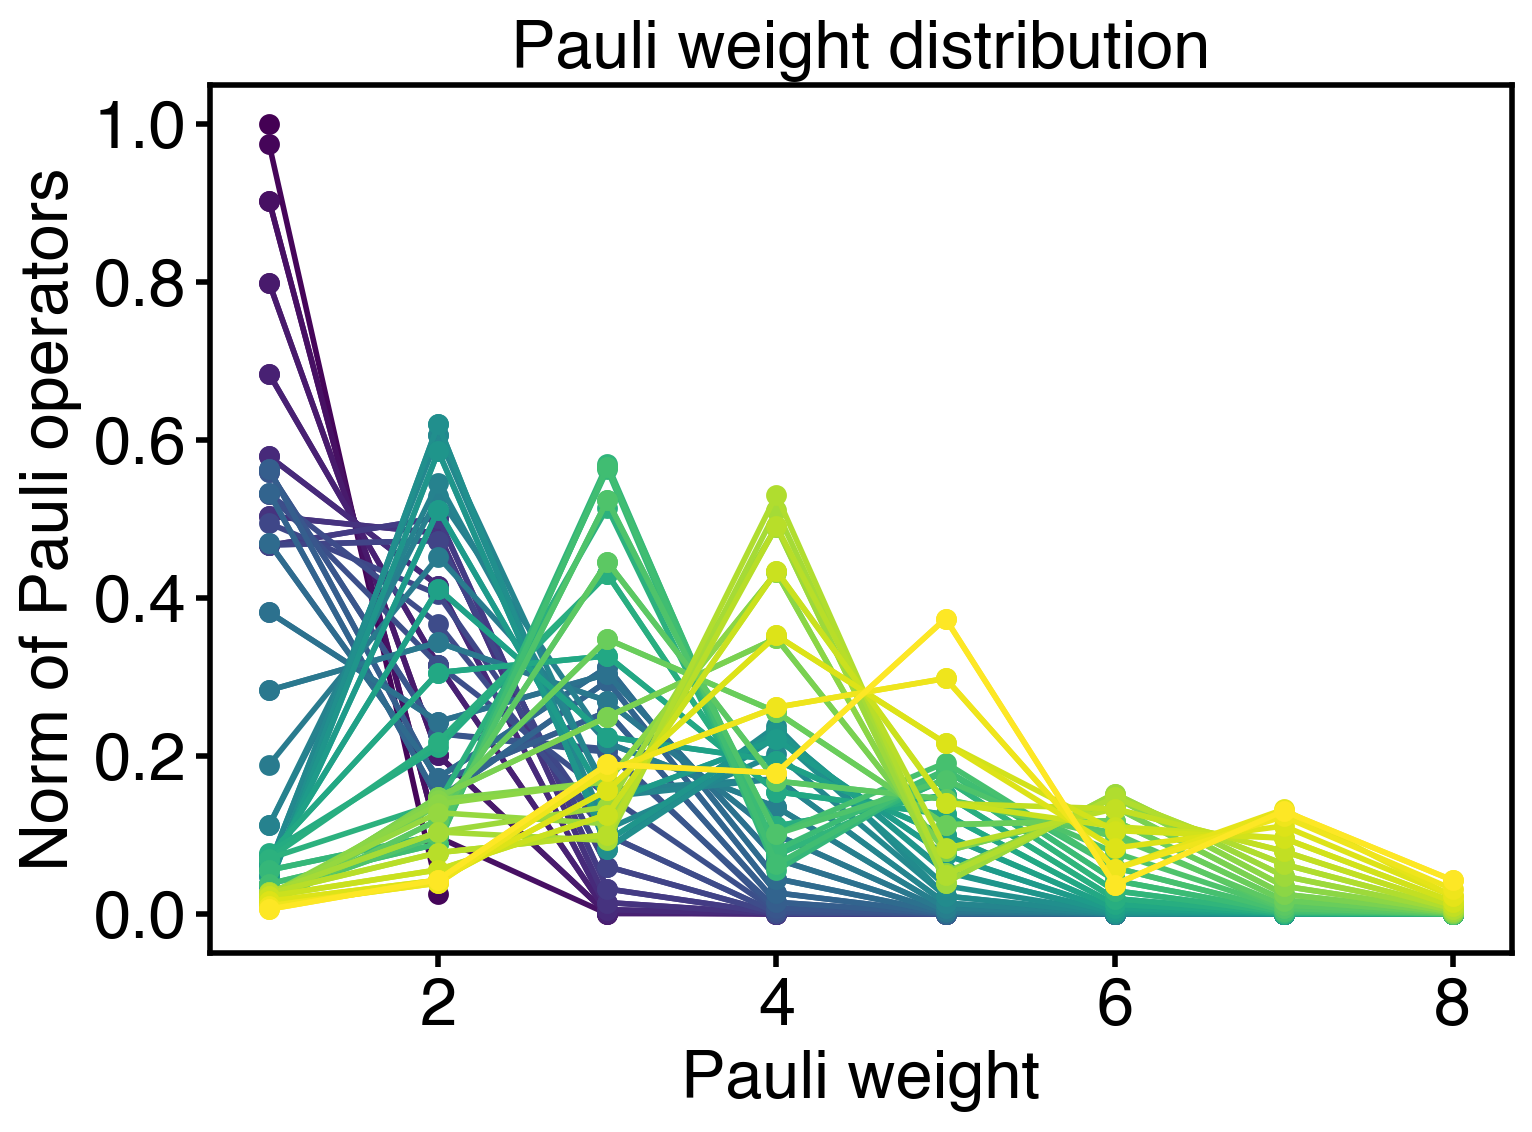

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
# use gradient color for each line
colors = plt.cm.viridis(np.linspace(0, 1, len(data_distribution)))
ax.set_prop_cycle(color=colors)
for i, item in enumerate(data_distribution):
    x = list(item.keys())
    y = [item[k] for k in x]
    ax.plot(x, y, label=f't={i*n}', marker='o', markersize=5, linewidth=2)
ax.set_xlabel('Pauli weight')
ax.set_ylabel('Norm of Pauli operators')
ax.set_title('Pauli weight distribution')